In [9]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import fitsio
from astropy.table import Table
from dsigma.helpers import dsigma_table
from dsigma.surveys.des import selection_response, multiplicative_shear_bias

# Load Catalog

DESI catalog crossed matched with DES shapes

In [4]:
datadir = '/scratch/network/jm8767/cl-lens'

desi_version = 'kibo' # 'kibo'
suffix_sources = '_iron' if desi_version == 'iron' else ''
datadir_desi = os.path.join(datadir, f'desi/spectro/redux/{desi_version}/zcatalog/v1')
run_string = '2026-05-16-21-16'

outdir = os.path.join(datadir, f'output-{run_string}/')

In [5]:
infile_desi = os.path.join(datadir_desi, f'zall-tilecumulative-{desi_version}.fits')

infile_sources = os.path.join(datadir, f'catalogs/des_y3_v0.50_v2026-03-12{suffix_sources}.hdf5')

In [10]:
table_s = Table.read(infile_sources, path='catalog')
z_spec_desi = table_s['z_spec_desi']
is_in_overlap_phot_spec_src_nside_64 = table_s['is_in_overlap_phot_spec_src_nside_64']

In [ ]:
table_s = dsigma_table(table_s, 'source', survey='DES') 
table_s['z_spec_desi'] = z_spec_desi
table_s['is_in_overlap_phot_spec_src_nside_64'] = is_in_overlap_phot_spec_src_nside_64

#for z_bin in range(4):
    #select = table_s['z_bin'] == z_bin
    #R_sel = selection_response(table_s[select])
    #table_s['R_11'][select] += 0.5 * np.sum(np.diag(R_sel))
    #table_s['R_22'][select] += 0.5 * np.sum(np.diag(R_sel))

table_s = table_s[table_s['z_bin'] >= 0]
table_s = table_s[table_s['flags_select']]
table_s['m'] = multiplicative_shear_bias(table_s['z_bin'], version='Y3')

In [13]:
table_s_spec = table_s.copy()
table_s_spec = table_s_spec[table_s_spec["z_spec_desi"] > 0]

print(f'Number of sources total: {len(table_s):,}')
print(f'Number of sources with spec-z: {len(table_s_spec):,}')

Number of sources total: 100,204,026
Number of sources with spec-z: 1,478,627


In [14]:
table_s_spec

z,ra,dec,w,e_1,e_2,z_bin,w_1p,w_1m,w_2p,w_2m,R_11,R_12,R_21,R_22,flags_select,flags_select_1p,flags_select_1m,flags_select_2p,flags_select_2m,z_spec_desi,is_in_overlap_phot_spec_src_nside_64,m
float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,float64,bool,float64
nan,44.678376310445955,0.4526577400807321,48.12962269577832,-0.020969228152792403,0.03230779078686742,0,48.12962269577832,48.12962269577832,48.12962269577832,48.12962269577832,0.6808127823468546,-0.0030661811231062763,-0.006353943633728362,0.6942338949074464,True,True,True,True,True,0.19258314582189645,True,-0.0063
nan,44.53274507545871,0.49187735626085183,65.45663276900477,0.04046585593611527,0.11980880234131522,0,65.45663276900477,65.45663276900477,65.45663276900477,65.45663276900477,0.6824723860812699,-0.014732059424907296,-0.0180433474484383,0.6793018949932491,True,True,True,True,True,0.3296374834417938,True,-0.0063
nan,44.594131556663186,0.5001954694764926,30.506274605436413,-0.3873189607351436,-0.13906740592624603,1,30.506274605436413,30.506274605436413,30.506274605436413,30.506274605436413,0.14529787720719536,0.13005274803494504,0.1181249327215278,1.0270310885501592,True,True,True,True,True,0.8766942872246418,True,-0.0198
nan,44.60103430678188,0.5044707023077456,71.87825361127477,0.11651704843652898,0.14578972054561,0,71.87825361127477,71.87825361127477,71.87825361127477,71.87825361127477,0.6690872555679447,-0.060117647986120126,-0.07042143648416793,0.6776118122921426,True,True,True,True,True,0.23676063274615505,True,-0.0063
nan,44.586475602370896,0.5213159888135216,40.29165002817832,-0.2299493601013802,-0.522920893598456,1,40.29165002817832,40.29165002817832,40.29165002817832,40.29165002817832,1.0864954135313463,-0.25872793695062846,-0.2837395196958359,0.7037919750635694,True,True,True,True,True,0.3313971206670543,True,-0.0198
nan,44.58070020734928,0.5277240169458649,25.47230489500281,0.08267480169536032,0.0473231969928131,3,25.47230489500281,25.47230489500281,25.47230489500281,25.47230489500281,1.1142515042990722,0.33016367112576395,0.22127223168698743,1.1552788727868393,True,True,True,True,True,1.2664775918247488,True,-0.0369
nan,44.46880068549997,0.49440953093317397,71.87825361127477,-0.06932651498848973,0.00096339962735623,0,71.87825361127477,71.87825361127477,71.87825361127477,71.87825361127477,0.7284154704745786,-0.007381019503649444,-0.016316897845547105,0.7110301328395577,True,True,True,True,True,0.17148843783168444,True,-0.0063
nan,44.48283819893848,0.510437427647998,34.19613965847937,-0.11325856700031776,-0.08840795289614992,1,32.868398577994064,32.868398577994064,32.868398577994064,32.868398577994064,0.2931766632371253,-0.13584941277243537,0.053245684695443773,0.8913936539370884,True,True,True,True,True,0.9552353440741685,True,-0.0198
nan,44.51477007186314,0.5060325665076906,70.78612899752909,0.030648794256712228,0.01992642306672929,0,70.78612899752909,70.78612899752909,70.78612899752909,70.78612899752909,0.6813476053462878,0.011095024023009478,0.020943093336798536,0.6887495825740784,True,True,True,True,True,0.3284442458343799,True,-0.0063


In [15]:
ra = table_s_spec['ra']
dec = table_s_spec['dec']
g1 = table_s_spec['e_1'] 
g2 = table_s_spec['e_2']
z = table_s_spec['z_spec_desi']

# Plots

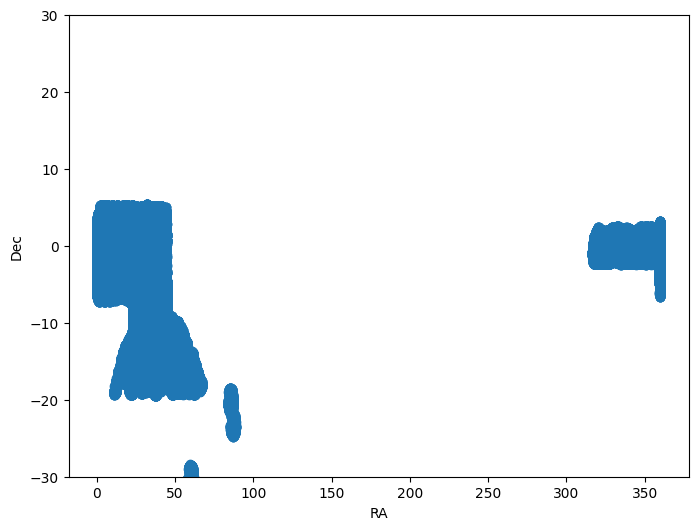

In [34]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
ax.set_ylim(-30, 30)
plt.show()

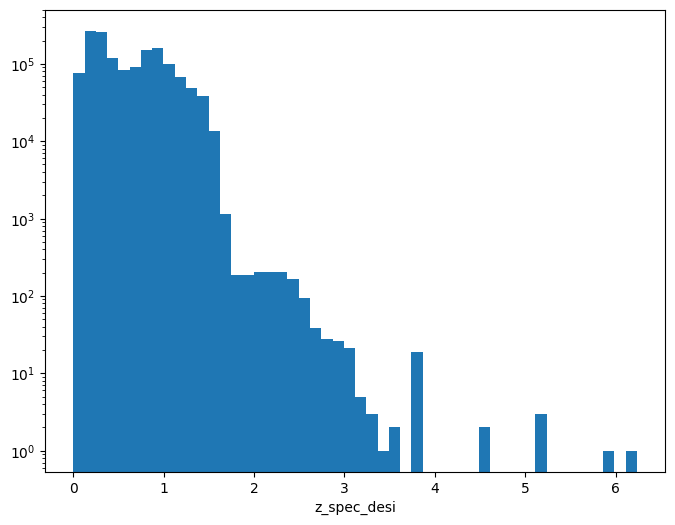

In [35]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [16]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [37]:
xip

array([ 5.09153547e-05,  3.86663315e-06,  5.11204239e-05, -2.01682360e-05,
       -1.89573282e-05,  2.67448397e-05, -3.12222799e-05,  5.80545360e-06,
        1.03153063e-05,  1.43117061e-06,  8.82927629e-06,  3.37784201e-06,
        4.72308594e-06,  1.50485099e-06, -1.18085092e-06,  1.82711195e-06,
        7.04402544e-07,  1.66427002e-06, -6.88177945e-07,  5.97736560e-08])

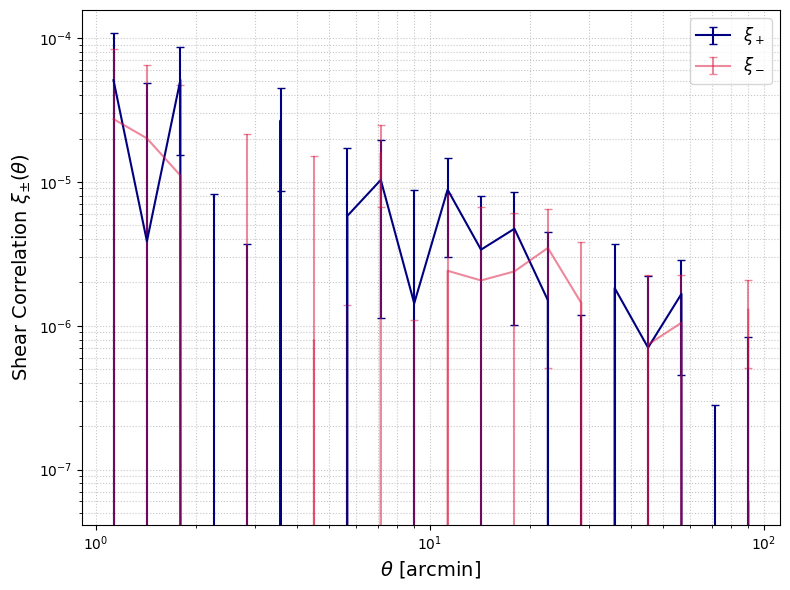

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

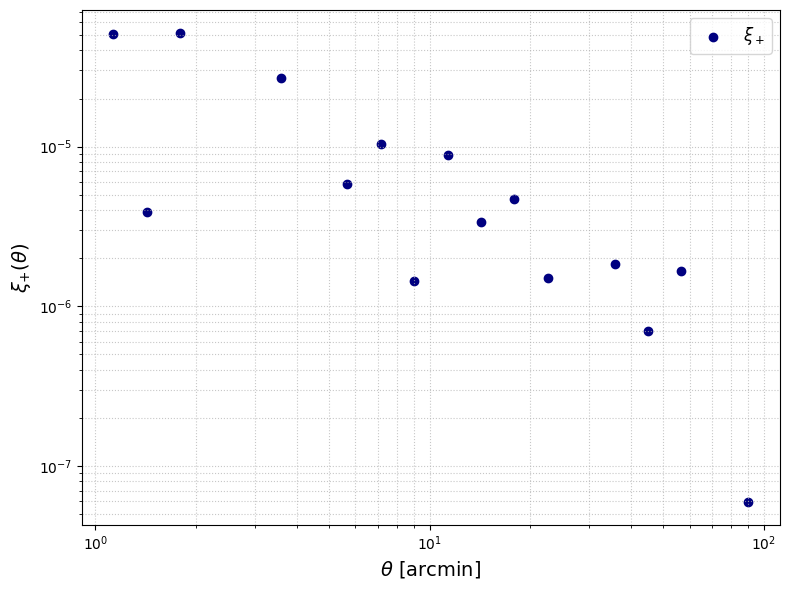

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()